In [2]:
pip install numpy pandas matplot scikit-learn 

  Using cached matplot-0.1.9-py2.py3-none-any.whl.metadata (241 bytes)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Prep


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\jeeva\OneDrive\Desktop\XGB_for_product_pred\env\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [6]:
df= pd.read_csv('data/loan_data.csv')
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


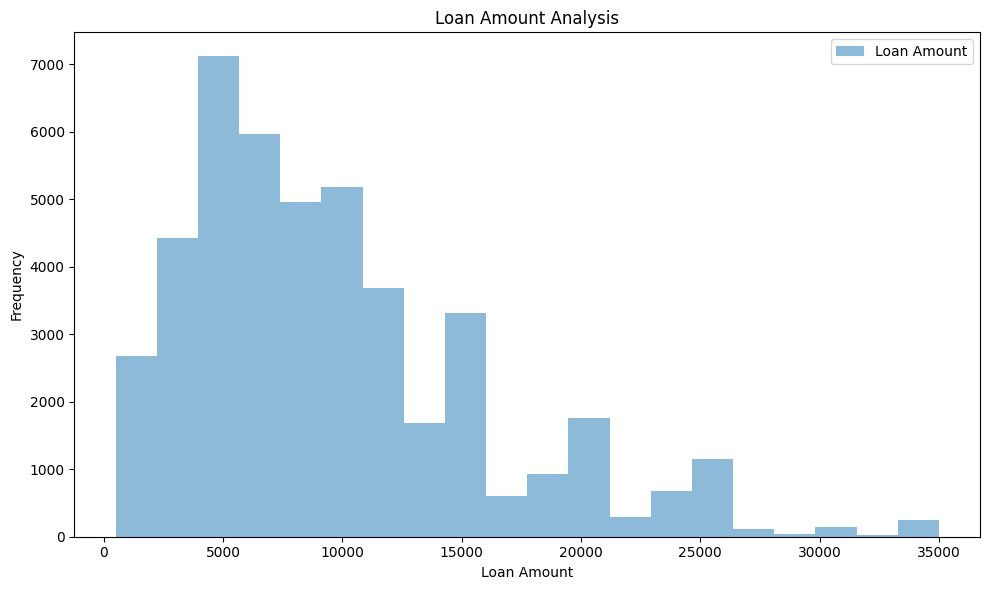

In [13]:
plt.figure(figsize=(10,6))
plt.hist(df['loan_amnt'],bins=20,alpha=0.5,label='Loan Amount')
plt.title('Loan Amount Analysis')
plt.xlabel("Loan Amount")
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
target_variable='loan_status'
X=df.drop(columns=target_variable)
y=df[target_variable]

numeric_columns=X.select_dtypes(include=np.number).columns
categorial_columns=X.select_dtypes(exclude=np.number).columns

print(f"Numberical columns:\n{numeric_columns.tolist()}")
print(f"Categorial columns:\n{categorial_columns.tolist()}")

Numberical columns:
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorial columns:
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train shape:{X_train.shape}")
print(f"test shape:{X_test.shape}")

Train shape:(36000, 13)
test shape:(9000, 13)


In [23]:
# Scale numeric features for Logistic, SVM, KNN and One hot encoding for categories
preprocess_scaled= ColumnTransformer(
    transformers=[('num',StandardScaler(),numeric_columns),
                   ('cat',OneHotEncoder(drop='first'),categorial_columns)]
)

In [28]:
def evalution_classifier_metric(name,model,X_test,y_test):

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test,y_pred,average="binary",zero_division=0)
    recall=recall_score(y_test,y_pred,average="binary",zero_division=0)

    print(f"\n{name}")
    print(f"\n Accuracy:{acc:.4f}")
    print(f"\n Precision:{prec:.4f}")
    print(f"\n Recall:{recall:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

    return acc,prec,recall
    


Logistic Regression

 Accuracy:0.8994

 Precision:0.7892

 Recall:0.7470


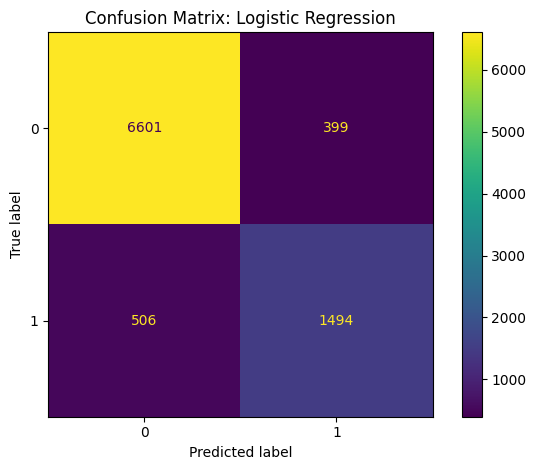

In [29]:
logreg=LogisticRegression(penalty='l2',max_iter=2000,random_state=42)
logreg_model= Pipeline(steps=[
    ("preprocess",preprocess_scaled),
    ("model",logreg)
])

logreg_model.fit(X_train,y_train)
acc_logreg,prec_logreg,recall_logreg=evalution_classifier_metric('Logistic Regression',logreg_model,X_test,y_test)


Support Vector Classifier

 Accuracy:0.9180

 Precision:0.8541

 Recall:0.7610


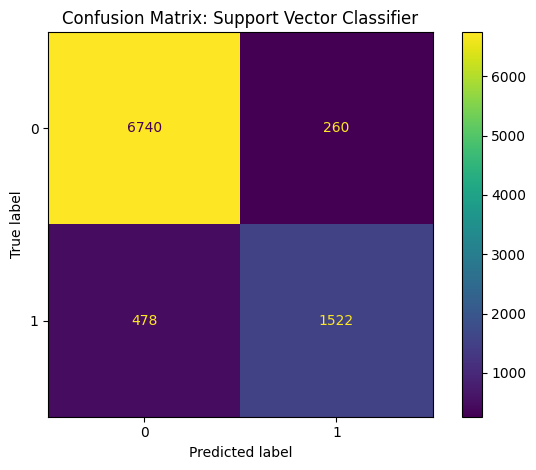

In [33]:
svm = SVC(kernel='rbf', C=1.0, random_state=42, gamma='scale')
svm_model = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", svm)
])

svm_model.fit(X_train, y_train)

acc_svm, prec_svm, rec_svm = evalution_classifier_metric("Support Vector Classifier", svm_model, X_test, y_test)


Random Forest

 Accuracy:0.9288

 Precision:0.8967

 Recall:0.7680


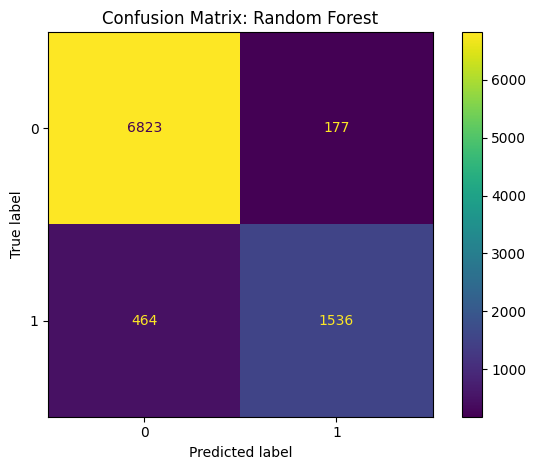

In [35]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", rf)
    ])

rf_model.fit(X_train, y_train)

acc_rf, prec_rf, rec_rf = evalution_classifier_metric("Random Forest", rf_model, X_test, y_test)

In [37]:
k_values=list(range(1,40,2))
accs=[]

for k in k_values:
    knn=Pipeline(steps=[
        ("preprocess",preprocess_scaled),
        ("model",KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    accs.append(accuracy_score(y_test,y_pred))

best_k=k_values[int(np.argmax(accs))]
print("Best K:",best_k)
print("Best_Accuracy:",max(accs))

Best K: 31
Best_Accuracy: 0.9052222222222223


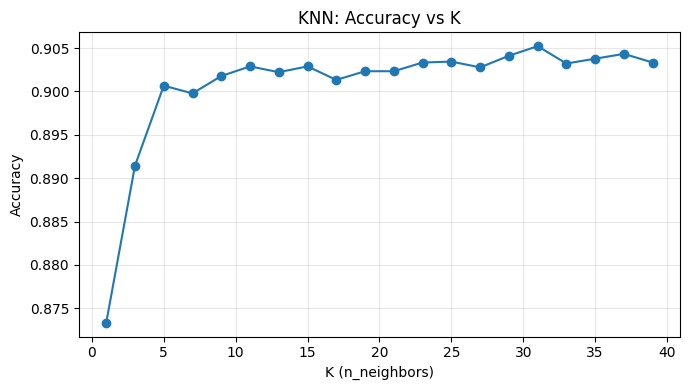

In [38]:
plt.figure(figsize=(7,4))
plt.plot(k_values, accs, marker="o")
plt.title("KNN: Accuracy vs K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KNN (K=31)

 Accuracy:0.9052

 Precision:0.8683

 Recall:0.6760


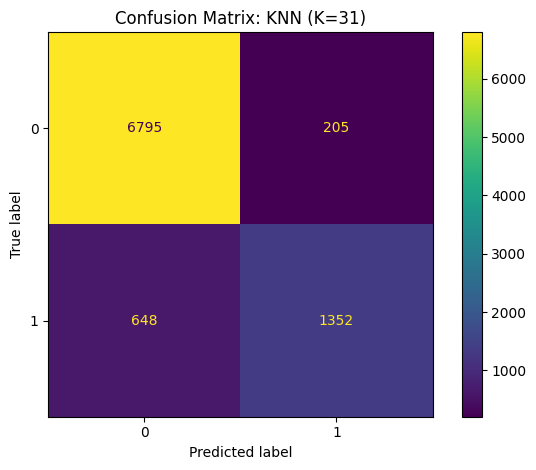

In [40]:
knn_best = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

knn_best.fit(X_train, y_train)

acc_knn, prec_knn, rec_knn = evalution_classifier_metric(f"KNN (K={best_k})", knn_best, X_test, y_test)